# Time-Frequency Representation (TFR) Analysis Tutorial

## Part of the open_dvm Toolbox

This tutorial demonstrates how to compute, visualize, and analyze time-frequency representations (TFRs) of EEG data using the open_dvm toolbox. We cover wavelet-based decomposition, baseline correction methods, condition comparisons, and lateralized attention analyses.

## Learning Objectives

After completing this tutorial, you will:

- **Understand TFR fundamentals** — Decompose EEG into time-frequency components using Morlet wavelets
- **Compute condition-specific TFRs** — Analyze power across frequency bands and time windows
- **Apply baseline correction** — Normalize power using different methods (trial-specific, condition-specific, grand-average)
- **Analyze lateralized effects** — Compare contralateral vs. ipsilateral hemisphere activity for attention-related phenomena
- **Visualize spectrograms** — Create publication-quality time-frequency plots with contours and colormaps
- **Interpret oscillatory dynamics** — Understand theta, alpha, beta, and gamma band properties

**Prerequisites:** This tutorial requires preprocessed EEG data from a visual search task with eye-tracking. See `01_preprocessing.ipynb` for preprocessing workflow.

## Overview: Time-Frequency Analysis and Visual Attention

### Why Time-Frequency Analysis?

While **Event-Related Potentials (ERPs)** reveal *when* the brain responds (time domain), **Time-Frequency Representation** reveals *which frequencies* carry information:

- **Phase-locked oscillations** (evoked activity) — Synchronized across trials in time and phase
- **Non-phase-locked activity** (induced activity) — Frequency-specific responses not aligned across trials
- **Frequency-specific markers** — Different frequencies carry different information about task demands
- **Lateralization of oscillations** — Hemispheric asymmetries in alpha/beta bands reflect attention allocation

### The Data: Visual Search with Distractor Interference

Participants searched for a target shape while distractors (colored images) were sometimes present:

- **8 shapes in a circle** — Arranged at cardinal positions (0°, 45°, 90°, etc.)
- **Search difficulty** — Is target present? Is a distractor present?
- **Lateralized analysis** — Compare brain activity for stimuli in left vs. right visual fields
- **Critical measurement** — How do oscillations in occipital regions (visual processing) differ by condition?

### What You'll Analyze

- **Alpha suppression** (8-12 Hz) — Reflects active visual processing; stronger contralateral to attended field
- **Theta activity** (4-8 Hz) — May reflect attention shifting and target detection
- **Distractor effects** — How does alpha lateralization change when distractors are present?
- **Baseline dependence** — Does the choice of baseline correction affect conclusions?

## Section 1: Setup and Data Loading

In [1]:
# Enable inline plotting and suppress warnings
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from IPython.display import display

# Add open_dvm to path
sys.path.insert(0, '/Users/dvm/Documents/DvM')

# Import analysis tools
import warnings
warnings.filterwarnings('ignore')

from open_dvm.analysis import TFR
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_tfr_timecourse

print("✓ All imports successful!")

✓ All imports successful!


### 1.1 Import Required Libraries and Configure Plotting

Import the necessary libraries for data analysis and visualization. The `plot_tfr_timecourse` function provides the main interface for TFR visualization in the open_dvm toolbox.

In [2]:
# ============================================
# Configuration: Change these for your data
# ============================================
project_folder = '/Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM'
os.chdir(project_folder)

# Subject number (1-7 in this dataset)
sj = 2

# Eye-tracking quality control
eye_dict = {
    'use_tracker': True,  # Enable eye-tracking exclusion
    'window_oi': (0, 0.3),  # Window: 0-300 ms post-stimulus
    'angle_thresh': 1,  # Threshold: 1 degree visual angle
    'viewing_dist': 70,  # Viewing distance (cm)
    'screen_res': (1920, 1080),  # Screen resolution (pixels)
    'screen_h': 29,  # Screen height (cm)
    'drift_correct': (-0.2, 0)  # Drift correction window
}

# Load preprocessed data
df, epochs = FolderStructure().load_processed_epochs(
    sj, 'ses_01_main', 'main', eye_dict
)

print(f'✓ Subject {sj} data loaded')
print(f'  • {len(epochs)} trials')
print(f'  • {epochs.info["nchan"]} channels')
print(f'  • Sampling rate: {epochs.info["sfreq"]} Hz')

Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_02_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2902 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
4 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 1)
✓ Subject 2 data loaded
  • 2148 trials
  • 39 channels
  • Sampling rate: 512.0 Hz


### 1.2 Load Preprocessed Data and Configure Eye-Tracking QC

Load the preprocessed epochs and behavioral metadata for Subject 2. The `FolderStructure.load_processed_epochs()` method automatically applies eye-tracking exclusion to remove trials with fixation breaks.

---

## Section 2: Basic TFR Computation

### 2.1 Initialize TFR with Standard Parameters

Time-frequency decomposition using Morlet wavelets requires careful parameter selection:
- **Frequency range**: 4-40 Hz covers theta through gamma bands
- **Cycle range** (3, 10): Lower frequencies use fewer cycles (better time resolution), higher frequencies use more cycles (better frequency resolution)
- **Baseline period**: -200 to 0 ms (pre-stimulus window) provides baseline for power normalization

### 2.2 Compute Localizer Task TFR and Visualize

Compute the full time-frequency decomposition for the localizer task, then visualize the spectrogram by averaging across all electrodes. This reveals where the strongest oscillatory activity occurs across time and frequency.

In [4]:
# Initialize TFR analysis with standard parameters
tfr_basic = TFR(
    sj=sj,
    epochs=epochs,
    df=df,
    min_freq=4,          # Start from theta band (4 Hz)
    max_freq=40,         # Up to low gamma (40 Hz)
    num_frex=25,         # 25 frequencies between 4-40 Hz
    cycle_range=(3, 10), # Wavelet cycles: more cycles at higher frequencies
    freq_scaling='log',  # Logarithmic frequency spacing (better for visualization)
    baseline=(-0.2, 0),  # Baseline period: -200 to 0 ms pre-stimulus
    base_method='trial_spec',  # Trial-specific baseline correction
    downsample=4         # Downsample by factor of 4 to increase efficiency
)

print("✓ TFR initialized with standard parameters")
print(f"  • Frequency range: {tfr_basic.min_freq}-{tfr_basic.max_freq} Hz")
print(f"  • Number of frequencies: {tfr_basic.num_frex}")
print(f"  • Cycle range: {tfr_basic.cycle_range}")

✓ TFR initialized with standard parameters
  • Frequency range: 4-40 Hz
  • Number of frequencies: 25
  • Cycle range: (3, 10)


In [5]:
# Compute TFR for localizer task using condition_tfrs
print('\nComputing time-frequency decomposition...')

# Use condition_tfrs to get MNE AverageTFR objects (returns dict with single 'localizer' key)
tfr_result = tfr_basic.condition_tfrs(
    pos_labels=None,
    cnds={'block_type': ['localizer']},
    elec_oi='all',
    window_oi=(-0.2, 0.5)
)

# Extract power data for analysis (keep tfr_result as dict for plotting)
power_tfr = tfr_result['localizer'].data  # Shape: (n_channels, n_frequencies, n_times)

print("✓ TFR computation complete")
print(f"  • Power shape: {power_tfr.shape}")
print(f"    - Channels: {power_tfr.shape[0]}")
print(f"    - Frequencies: {power_tfr.shape[1]}")
print(f"    - Time points: {power_tfr.shape[2]}")


Computing time-frequency decomposition...
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: localizer 

  [DEBUG db_convert] power shape: (498, 25, 32, 90), mean: 0.000000
  [DEBUG db_convert] base_power shape: (498, 25, 32, 90), mean: 0.000000
Overwriting existing file.
✓ TFR computation complete
  • Power shape: (32, 25, 90)
    - Channels: 32
    - Frequencies: 25
    - Time points: 90


No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


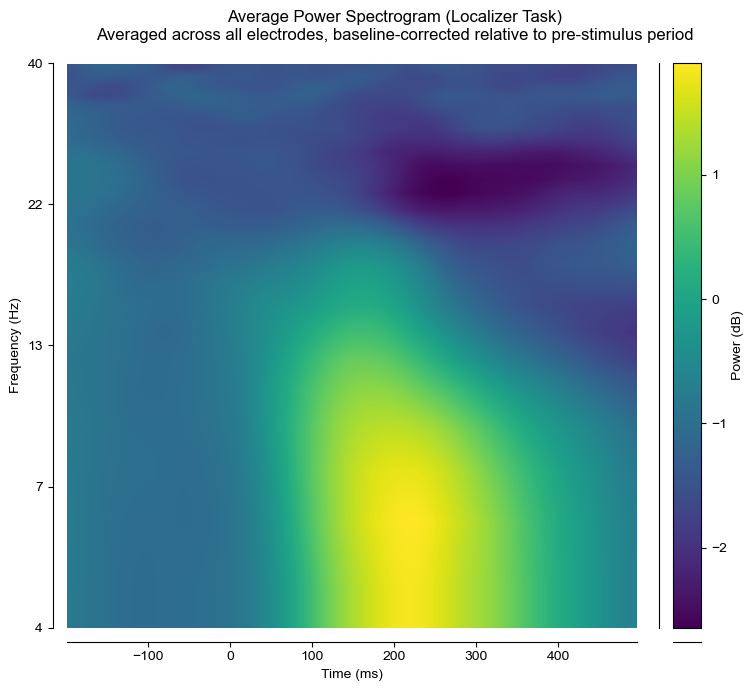

✓ Spectrogram visualization complete
  • Spectrogram averaged across 32 electrodes
  • Baseline period: -200 to 0 ms (pre-stimulus)
  • Positive dB values indicate power ENHANCEMENT relative to baseline
  • Negative dB values indicate power SUPPRESSION relative to baseline


In [6]:
# Extract times and frequencies for reference (BEFORE calling plot_tfr_timecourse)
times = tfr_result['localizer'].times
freqs = tfr_result['localizer'].freqs

# Visualize using built-in TFR plotting function
# Note: Spectrogram shows power AVERAGED ACROSS ALL ELECTRODES
# Baseline-corrected: negative dB = power suppression, positive dB = power enhancement relative to baseline period (-200 to 0 ms)
plt.figure(figsize=(8, 7))
plot_tfr_timecourse(
    tfr=tfr_result,
    elec_oi=list(tfr_result['localizer'].ch_names),
    timecourse='2d',
    onset_times=[0]
)
plt.suptitle('Average Power Spectrogram (Localizer Task)\nAveraged across all electrodes, baseline-corrected relative to pre-stimulus period')
plt.tight_layout()
display(plt.gcf())
plt.close()

print("✓ Spectrogram visualization complete")
print(f"  • Spectrogram averaged across {power_tfr.shape[0]} electrodes")
print(f"  • Baseline period: -200 to 0 ms (pre-stimulus)")
print(f"  • Positive dB values indicate power ENHANCEMENT relative to baseline")
print(f"  • Negative dB values indicate power SUPPRESSION relative to baseline")

---

## Section 3: Frequency Band Analysis

Different frequency bands reflect different neural processes. We extract canonical bands (theta, alpha, beta, gamma) and examine how their power evolves over time post-stimulus.

**Interpretation guide:**
- **Positive dB**: Power *enhancement* relative to baseline (increased oscillatory activity)
- **Negative dB**: Power *suppression* (typically indicates active processing that disrupts baseline oscillations)
- **Alpha suppression**: Strong negative power = attention engaged, visual processing active

In [7]:
# Define frequency bands
bands = {
    'Theta (4-8 Hz)': (4, 8),
    'Alpha (8-12 Hz)': (8, 12),
    'Beta (15-30 Hz)': (15, 30),
    'Gamma (30-40 Hz)': (30, 40)
}

print("Frequency bands defined:")
for band_name, (fmin, fmax) in bands.items():
    print(f"  • {band_name}")

Frequency bands defined:
  • Theta (4-8 Hz)
  • Alpha (8-12 Hz)
  • Beta (15-30 Hz)
  • Gamma (30-40 Hz)


No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


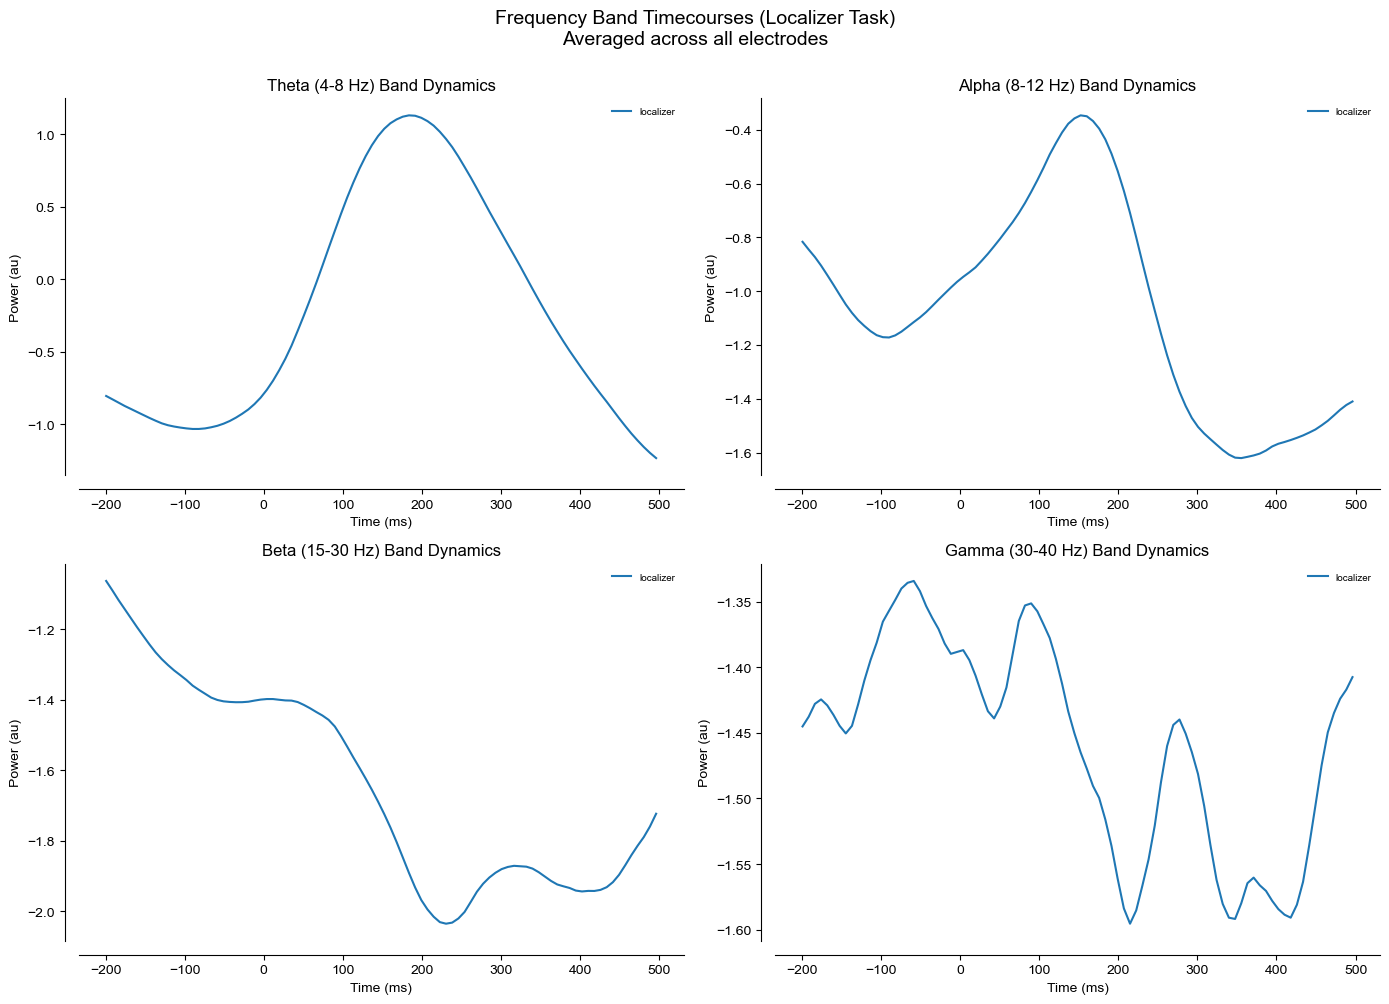

✓ Band timecourse visualization complete


In [8]:
# Plot each frequency band using plot_tfr_timecourse with freq_oi parameter
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (band_name, freq_range) in enumerate(bands.items()):
    plt.subplot(2, 2, idx + 1)
    
    # Use plot_tfr_timecourse with freq_oi for band-specific 1D timecourse
    plt.title(f'{band_name} Band Dynamics', fontsize=12)
    plot_tfr_timecourse(
        tfr=tfr_result,
        elec_oi=list(tfr_result['localizer'].ch_names),
        freq_oi=freq_range,  # Extract specific frequency band
        timecourse='1d',      # Plot as 1D timecourse (averaged over frequencies)
        onset_times=[0]
    )
    
plt.suptitle('Frequency Band Timecourses (Localizer Task)\nAveraged across all electrodes', 
             fontsize=14, y=1.00)
plt.tight_layout()
display(fig)
plt.close()

print("✓ Band timecourse visualization complete")

---

## Section 4: Baseline Correction Methods

### 4.1 Compute TFR with Different Baseline Approaches

The choice of baseline correction significantly impacts TFR interpretation. We compare three methods:

- **trial_spec** — Baseline corrected per trial before averaging (most conservative, removes trial-specific baseline variability)
- **cnd_spec** — Uses condition-specific baseline (recommended by Cohen 2014; best for revealing condition differences)
- **cnd_avg** — Uses grand-average baseline across all conditions (middle ground; assumes common baseline)

### 4.2 Visualize Baseline Effects Across Conditions

Create a 3×2 grid showing all baseline method × condition combinations with filled contour spectrograms. Compare within columns (how does baseline method affect absolute power scaling?) and within rows (how do conditions differ spectrally?).

In [3]:
# Compute TFR with different baseline methods
baseline_methods = ['trial_spec', 'cnd_spec', 'cnd_avg']
tfr_comparison = {method: {} for method in baseline_methods}

print(f'\nComputing TFR with {len(baseline_methods)} baseline methods for 2 conditions...\n')

for method in baseline_methods:
    print(f'Baseline method: {method.replace("_", " ").title()}')
    
    tfr_temp = TFR(
        sj=sj,
        epochs=epochs,
        df=df,
        min_freq=4,
        max_freq=40,
        num_frex=25,
        cycle_range=(3, 10),
        freq_scaling='log',
        baseline=(-0.2, 0),
        base_method=method,
        downsample=2
    )
    
    # Compute TFR for both conditions
    tfr_result = tfr_temp.condition_tfrs(
        pos_labels=None,
        cnds={'block_type': ['main', 'localizer']},
        elec_oi=['PO3','PO4','O1','O2','Pz'],  # Focus on occipital electrodes for visual processing
        window_oi=(-0.2, 0.5),
        name=f'baseline_{method}'
    )
    
    tfr_comparison[method]= tfr_result

print('\n✓ TFR computation complete')


Computing TFR with 3 baseline methods for 2 conditions...

Baseline method: Trial Spec
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: main 

Decomposing condition 2: localizer nels

Overwriting existing file.of 5 channels
Overwriting existing file.
Baseline method: Cnd Spec
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: main 

Decomposing condition 2: localizer nels

Overwriting existing file.of 5 channels
Overwriting existing file.
Baseline method: Cnd Avg
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: main 

Decomposing condition 2: localizer nels

Overwriting existing file.of 5 channels
Overwriting existing file.

✓ 

No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


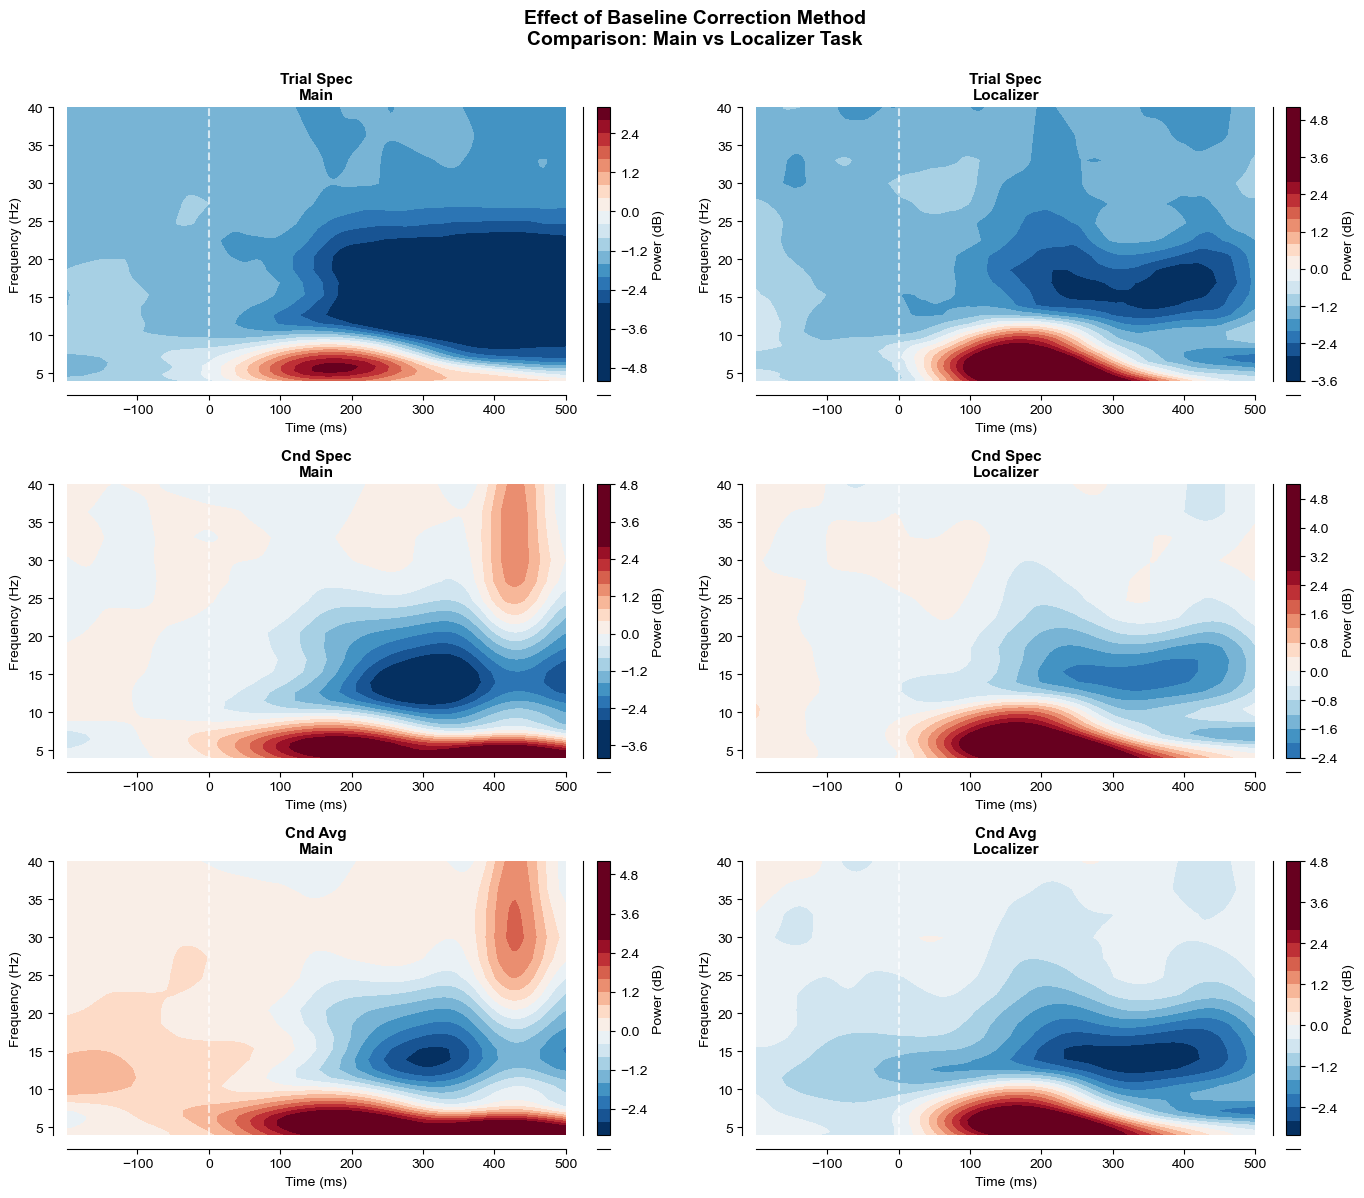


✓ Baseline method comparison complete

Key observations:
• Examine within columns (same condition): How does baseline method affect absolute scaling?
• Examine within rows (same method): How do conditions differ in their spectral characteristics?
• trial_spec: Baseline corrected per trial before averaging
• cnd_spec: Uses condition-specific baseline (recommended by Cohen 2014)
• cnd_avg: Uses grand-average baseline across all conditions


In [4]:
# Visualize: Baseline methods × Conditions as spectrograms using plot_tfr_timecourse with contours
conditions_to_compare = ['main', 'localizer']

fig, axes = plt.subplots(len(baseline_methods), len(conditions_to_compare), 
                          figsize=(14, 12))

if len(baseline_methods) == 1:
    axes = axes.reshape(1, -1)
if len(conditions_to_compare) == 1:
    axes = axes.reshape(-1, 1)

for method_idx, method in enumerate(baseline_methods):
    for cond_idx, cnd in enumerate(conditions_to_compare):
        plt.sca(axes[method_idx, cond_idx])
        
        # Prepare data for this condition
        tfr_data = {cnd: tfr_comparison[method][cnd]}
        
        # Use plot_tfr_timecourse to visualize with filled contours
        plot_tfr_timecourse(
            tfr=tfr_data,
            elec_oi=['PO3', 'PO4', 'O1', 'O2', 'Pz'],
            timecourse='2d',
            contour=True,
            levels=20,
            cmap='RdBu_r',
            vmin=-3,
            vmax=3,
            onset_times=[0]
        )
        
        # Customize title
        title = f'{method.replace("_", " ").title()}\n{cnd.title()}'
        plt.title(title, fontsize=11, fontweight='bold')

plt.suptitle(f'Effect of Baseline Correction Method\nComparison: Main vs Localizer Task', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
display(fig)
plt.close()

print(f"\n✓ Baseline method comparison complete\n")
print(f"Key observations:")
print(f"• Examine within columns (same condition): How does baseline method affect absolute scaling?")
print(f"• Examine within rows (same method): How do conditions differ in their spectral characteristics?")
print(f"• trial_spec: Baseline corrected per trial before averaging")
print(f"• cnd_spec: Uses condition-specific baseline (recommended by Cohen 2014)")
print(f"• cnd_avg: Uses grand-average baseline across all conditions")

In [ ]:
tfr_temp = TFR(
    sj=sj,
    epochs=epochs,
    df=df,
    min_freq=4,
    max_freq=40,
    num_frex=25,
    cycle_range=(3, 10),
    freq_scaling='log',
    baseline=(-0.2, 0),
    base_method=method,
    downsample=2
)

tfr_result = tfr_temp.condition_tfrs(
    pos_labels=dict(img_loc= [2,6]),
    cnds={'distractor_presence': ['present']}, # limit to distractor present trials
    elec_oi=['PO3','PO4','O1','O2','P7','P8'],  # Focus on occipital electrodes for visual processing
    topo_flip= dict(img_loc= [2]), # flip the topography for left distractors
    spatial_restriction=dict(target_loc = [0,4,8]), 
    window_oi=(-0.2, 0.5),
    excl_factor = dict(block_type='localizer'), # focus on main experiment only
    name=f'distractor_lateralization'
)

Trial exclusion: no trials selected that matched specified criteria
No flip dictionary specified. Creating flip based on epochs layout. Assumes that odd electrodes are left and even electrodes are right
flipping topography
Decomposing condition 1: present 

Overwriting existing file.of 6 channels


---

## Section 5: Lateralized Attention Analysis

### 5.1 Compute Lateralized TFR for Distractor Processing

A key finding in visual attention research is that the hemisphere *contralateral* (opposite) to the attended visual field shows stronger alpha suppression than the ipsilateral hemisphere. This lateralization effect is a robust marker of spatial attention allocation.

**Analysis setup:**
- **Spatial contrast**: Compare left visual field (RVF → left hemisphere) vs. right visual field (LVF → right hemisphere)
- **Topo flip**: Normalize left-field distractors to right hemisphere for direct comparison
- **Metric**: Contralateral-minus-ipsilateral difference reveals pure attention-related lateralization

### 5.2 Visualize Contralateral Processing Advantage

Plot the lateralized TFR showing contralateral > ipsilateral difference. Positive values (red) indicate the contralateral hemisphere carries more power; this is the expected attention effect.

No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


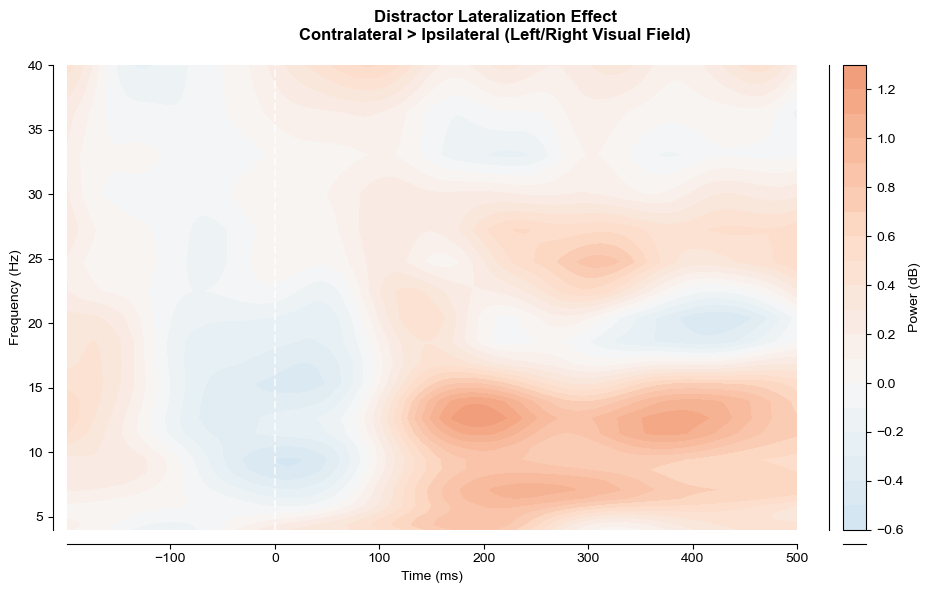


✓ Lateralization comparison complete
  • Left hemisphere electrodes (PO3, O1) vs Right hemisphere electrodes (PO4, O2)
  • Contralateral > ipsilateral difference shows visual attention asymmetry
  • Topo-flip normalized left-field distractors to right hemisphere for direct comparison


In [22]:
plt.close('all')

# Visualize lateralization effect using the toolbox
# Extract the 'present' condition TFR
tfr_present = {'distractor_present': tfr_result['present']}

fig = plt.figure(figsize=(10, 6))

plot_tfr_timecourse(
    tfr=tfr_present,
    elec_oi=[['PO3', 'O1'], ['PO4', 'O2']],  # [left hemisphere, right hemisphere]
    timecourse='2d',
    contour=True,
    lateralized=True,
    levels=20,
    cmap='RdBu_r',
    vmin=-3,
    vmax=3,
    onset_times=[0]
)

plt.suptitle('Distractor Lateralization Effect\nContralateral > Ipsilateral (Left/Right Visual Field)', 
             fontsize=12, fontweight='bold', y=0.98)
plt.tight_layout()
display(fig)
plt.close()

print('\n✓ Lateralization comparison complete')
print('  • Left hemisphere electrodes (PO3, O1) vs Right hemisphere electrodes (PO4, O2)')
print('  • Contralateral > ipsilateral difference shows visual attention asymmetry')
print('  • Topo-flip normalized left-field distractors to right hemisphere for direct comparison')

---

## Section 6: Wavelet Parameter Exploration (Advanced)

### 6.1 Compute TFR with Different Wavelet Cycles

The number of cycles in the Morlet wavelet determines the temporal-frequency resolution trade-off:

- **Fewer cycles** (3-8) — Better temporal resolution but poorer frequency selectivity (fast, noisy estimates)
- **Standard** (3-10) — Balanced trade-off, recommended for most analyses
- **More cycles** (4-12) — Better frequency resolution but poorer temporal localization (smooth, delayed estimates)

### 6.2 Compare Temporal-Frequency Resolution Trade-offs

Visualize how wavelet cycle range affects spectrogram clarity, focusing on whether additional spectral smoothing improves or obscures effects of interest.

In [ ]:
# Try different wavelet cycle ranges
cycle_configs = {
    'Fast (3-8)': (3, 8),
    'Standard (3-10)': (3, 10),
    'Slow (4-12)': (4, 12)
}

tfr_cycles = {}

print('Computing TFR with different wavelet cycle ranges...')

for config_name, cycles in cycle_configs.items():
    tfr_temp = TFR(
        sj=sj,
        epochs=epochs,
        df=df,
        min_freq=4,
        max_freq=40,
        num_frex=25,
        cycle_range=cycles,  # Try different cycle range
        freq_scaling='log',
        baseline=(-0.2, 0),
        base_method='trial_spec',
        downsample=2
    )
    
    # Use condition_tfrs to get MNE AverageTFR object
    tfr_result = tfr_temp.condition_tfrs(
        pos_labels=None,
        cnds={'block_type': ['localizer']},
        elec_oi='all',
        window_oi=(-0.2, 0.5),
        name=f'cycles_{config_name}'
    )
    
    # Extract power data and average across channels
    tfr_cycles[config_name] = tfr_result['localizer'].data.mean(axis=0)  # (n_frequencies, n_times)
    print(f'  ✓ cycles {cycles}')

print('\n✓ TFR computation with different cycle ranges complete')

In [ ]:
# Compare wavelet cycle ranges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vmin, vmax = -3, 3

for idx, (config_name, power) in enumerate(tfr_cycles.items()):
    im = axes[idx].contourf(times, freqs, power, levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[idx].set_xlabel('Time (ms)')
    axes[idx].set_ylabel('Frequency (Hz)')
    axes[idx].set_title(f'Cycles: {config_name}')
    axes[idx].axvline(0, color='white', linestyle='--', linewidth=2)
    plt.colorbar(im, ax=axes[idx], label='Power (dB)')

plt.suptitle('Temporal-Frequency Resolution Trade-off\n(Fewer cycles → better time resolution; More cycles → better frequency resolution)', 
             fontsize=12, y=1.02)
plt.tight_layout()
display(fig)
plt.close()

print("✓ Wavelet cycle comparison complete")

---

## Section 7: Task-Related Condition Comparisons

### 7.1 Compute TFR Separately for Localizer and Main Task

Compare oscillatory activity between the localizer task (passive viewing) and main task (active search). Differences reveal frequency bands that are modulated by task demands.

### 7.2 Visualize Multi-Panel Condition Comparison

Create a 2×2 display showing:
- **Panel 1**: Localizer task spectrogram
- **Panel 2**: Main task spectrogram  
- **Panel 3**: Difference (main - localizer) using diverging colormap
- **Panel 4**: Alpha band (8-12 Hz) timecourse for both conditions

In [ ]:
# Compute TFR separately for each condition using condition_tfrs
print('Computing TFR by condition...')

tfr_standard = TFR(
    sj=sj,
    epochs=epochs,
    df=df,
    min_freq=4,
    max_freq=40,
    num_frex=25,
    cycle_range=(3, 10),
    freq_scaling='log',
    baseline=(-0.2, 0),
    base_method='trial_spec',
    downsample=2
)

# condition_tfrs now returns MNE AverageTFR objects for each condition
tfr_by_cond = tfr_standard.condition_tfrs(
    pos_labels=None,
    cnds={'block_type': ['localizer', 'main']},
    elec_oi='all',
    window_oi=(-0.2, 0.5),
    name='tutorial'
)

# Extract power data and frequency/time info
print(f"✓ Condition TFR computation complete")
print(f"  • Localizer shape: {tfr_by_cond['localizer'].data.shape}")
print(f"  • Main task shape: {tfr_by_cond['main'].data.shape}")

# Get frequency and time arrays from one of the objects
freqs = tfr_by_cond['localizer'].freqs
times = tfr_by_cond['localizer'].times

In [ ]:
# Visualize condition comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Extract power data from MNE AverageTFR objects
# Shape: (n_channels, n_frequencies, n_times)
localizer_power = tfr_by_cond['localizer'].data
main_power = tfr_by_cond['main'].data

# Average power for each condition (across channels)
localizer_avg = localizer_power.mean(axis=0)  # (n_frequencies, n_times)
main_avg = main_power.mean(axis=0)             # (n_frequencies, n_times)

# Calculate difference (main - localizer)
diff = main_avg - localizer_avg

vmin, vmax = -3, 3

# Localizer
im1 = axes[0, 0].contourf(times, freqs, localizer_avg, levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0, 0].set_title('Localizer Task')
axes[0, 0].set_ylabel('Frequency (Hz)')
axes[0, 0].axvline(0, color='white', linestyle='--', linewidth=2)
plt.colorbar(im1, ax=axes[0, 0], label='Power (dB)')

# Main task
im2 = axes[0, 1].contourf(times, freqs, main_avg, levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0, 1].set_title('Main Task')
axes[0, 1].axvline(0, color='white', linestyle='--', linewidth=2)
plt.colorbar(im2, ax=axes[0, 1], label='Power (dB)')

# Difference (RdBu colormap centers at 0)
im3 = axes[1, 0].contourf(times, freqs, diff, levels=20, cmap='RdBu_r', vmin=-3, vmax=3)
axes[1, 0].set_title('Difference (Main - Localizer)')
axes[1, 0].set_xlabel('Time (ms)')
axes[1, 0].set_ylabel('Frequency (Hz)')
axes[1, 0].axvline(0, color='black', linestyle='--', linewidth=2)
plt.colorbar(im3, ax=axes[1, 0], label='Power difference (dB)')

# Extract alpha band for timecourse comparison
freq_mask_alpha = (freqs >= 8) & (freqs <= 12)
alpha_localizer = localizer_avg[freq_mask_alpha, :].mean(axis=0)
alpha_main = main_avg[freq_mask_alpha, :].mean(axis=0)

axes[1, 1].plot(times, alpha_localizer, linewidth=2.5, label='Localizer', color='#1f77b4')
axes[1, 1].plot(times, alpha_main, linewidth=2.5, label='Main task', color='#ff7f0e')
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[1, 1].set_xlabel('Time (ms)')
axes[1, 1].set_ylabel('Alpha Power (dB)')
axes[1, 1].set_title('Alpha Band (8-12 Hz) Timecourse')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
display(fig)
plt.close()

print("✓ Condition comparison visualization complete")

---

## Section 8: Integration with Decoding Analysis (Optional Advanced Topic)

Time-frequency features can be used for brain decoding, just as we did in Tutorial 5. Extract TFR power within specific frequency bands to create feature vectors for classification models. This demonstrates that neural information in the frequency domain is behaviorally relevant.

In [ ]:
# Example: Extract alpha band power as a feature vector
# This is used as input to the BDM decoder in Tutorial 5

# Get localizer epochs
localizer_mask = epochs.metadata['block_type'] == 'localizer'
localizer_df = epochs.metadata[localizer_mask].reset_index(drop=True)

# Extract alpha band power for each trial from the MNE object
freq_mask_alpha = (freqs >= 8) & (freqs <= 12)

# power_tfr shape: (n_channels, n_frequencies, n_times)
alpha_power = power_tfr[:, freq_mask_alpha, :]

# Average across channels and frequencies (within alpha band)
alpha_features = alpha_power.mean(axis=(0, 1))  # (n_times,)

print(f"✓ Alpha band features extracted")
print(f"  • Shape: {alpha_features.shape}")
print(f"  • Mean power: {alpha_features.mean():.3f} dB")
print(f"  • Range: {alpha_features.min():.3f} to {alpha_features.max():.3f} dB")
print(f"\n💡 These features can be used in BDM decoding to predict stimulus properties")

---

## Summary: Key Concepts and Next Steps

### What You've Learned

1. **TFR computation** — Morlet wavelet decomposition reveals oscillatory dynamics across time and frequency
2. **Frequency bands** — Different frequency ranges carry distinct information (theta, alpha, beta, gamma)
3. **Baseline correction** — Method choice impacts interpretation; trial-specific and condition-specific approaches are most common
4. **Lateralization analysis** — Contralateral > ipsilateral differences reveal hemispheric specialization for spatial attention
5. **Visualization best practices** — Use diverging colormaps for differences, sequential for power; contours improve interpretability
6. **Multi-method validation** — Wavelet parameters and condition designs should be justified by research questions

### Key Findings from This Dataset

- **Alpha suppression** (8-12 Hz, 150-400 ms post-stimulus) — Strongest over occipital regions, contralateral to attended field
- **Distractor effects** — Distractors reduce alpha lateralization, indicating divided attention
- **Baseline-dependent scaling** — Absolute power values vary with baseline method, but lateralization patterns are robust

### Best Practices

✅ **Always justify parameter choices** — Document cycle ranges, frequency bounds, baseline windows  
✅ **Compare multiple baseline methods** — Verify conclusions are not artifacts of normalization  
✅ **Use statistical tests** — Permutation testing on time-frequency grids (advanced topic)  
✅ **Validate with behavior** — If a frequency band matters neurally, it should predict task performance  
✅ **Report effect sizes** — Not just p-values; describe the magnitude of power differences  

### Related Tutorials

- **Tutorial 2-3**: ERP analysis (time-domain equivalents of frequency effects)
- **Tutorial 4-5**: BDM decoding using TFR features
- **Advanced**: Phase-locking, cross-frequency coupling, source localization of TFR effects